# Experiment -1




Final Weights: [0.2 0.1]
Final Bias: -0.20000000000000004
Decision Boundary: 0.2*x1 + 0.1*x2 + (-0.20000000000000004) = 0

Predictions:
Input: [0 0]  True: 0  Predicted: 0
Input: [0 1]  True: 0  Predicted: 0
Input: [1 0]  True: 0  Predicted: 0
Input: [1 1]  True: 1  Predicted: 1


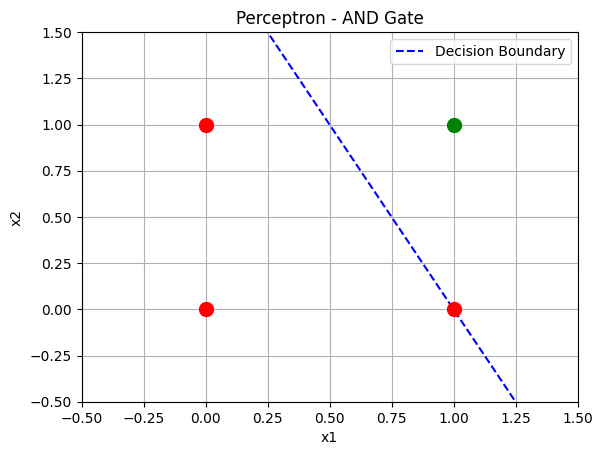

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset - AND Gate
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0, 0, 0, 1])

# Perceptron Training
weights = np.zeros(2)
bias = 0
lr = 0.1
epochs = 10

for epoch in range(epochs):
    for i in range(len(X)):
        linear_output = np.dot(X[i], weights) + bias
        y_pred = 1 if linear_output >= 0 else 0
        update = lr * (y[i] - y_pred)
        weights += update * X[i]
        bias += update

print("Final Weights:", weights)
print("Final Bias:", bias)
print(f"Decision Boundary: {weights[0]}*x1 + {weights[1]}*x2 + ({bias}) = 0")

# Predictions
print("\nPredictions:")
for xi, yi in zip(X, y):
    out = np.dot(xi, weights) + bias
    pred = 1 if out >= 0 else 0
    print(f"Input: {xi}  True: {yi}  Predicted: {pred}")

# Plot
x1_vals = np.linspace(-0.5, 1.5, 100)
x2_vals = -(weights[0] * x1_vals + bias) / weights[1]
for xi, yi in zip(X, y):
    plt.scatter(*xi, color='green' if yi == 1 else 'red', s=100, zorder=5)
plt.plot(x1_vals, x2_vals, 'b--', label='Decision Boundary')
plt.xlim(-0.5, 1.5); plt.ylim(-0.5, 1.5)
plt.xlabel('x1'); plt.ylabel('x2')
plt.title('Perceptron - AND Gate'); plt.legend(); plt.grid(True); plt.show()

# Experiment -3



In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Dataset - Iris
data = load_iris()
X = StandardScaler().fit_transform(data.data.astype(np.float32))
y = tf.keras.utils.to_categorical(data.target, 3)
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 5 Hyperparameter Trials
trials = [
    {'lr': 0.001, 'units': 32,  'batch': 16, 'dropout': 0.0},
    {'lr': 0.01,  'units': 64,  'batch': 16, 'dropout': 0.2},
    {'lr': 0.01,  'units': 64,  'batch': 32, 'dropout': 0.3},
    {'lr': 0.001, 'units': 128, 'batch': 32, 'dropout': 0.4},
    {'lr': 0.01,  'units': 32,  'batch': 32, 'dropout': 0.5},
]

for i, t in enumerate(trials, 1):
    m = models.Sequential([
        layers.Dense(t['units'], activation='relu', input_shape=(4,)),
        layers.Dropout(t['dropout']),
        layers.Dense(t['units'], activation='relu'),
        layers.Dense(3, activation='softmax')
    ])
    m.compile(optimizer=optimizers.Adam(t['lr']),
              loss='categorical_crossentropy', metrics=['accuracy'])
    m.fit(X_tr, y_tr, epochs=50, batch_size=t['batch'], verbose=0)

    tr_loss, tr_acc = m.evaluate(X_tr, y_tr, verbose=0)
    val_loss, val_acc = m.evaluate(X_val, y_val, verbose=0)
    overfit = "Yes" if tr_acc - val_acc > 0.05 else "No"
    print(f"Trial {i} | LR={t['lr']} Units={t['units']} Batch={t['batch']} Dropout={t['dropout']} "
          f"| Train Loss={tr_loss:.4f} | Val Acc={val_acc:.4f} | Overfit={overfit}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Trial 1 | LR=0.001 Units=32 Batch=16 Dropout=0.0 | Train Loss=0.0892 | Val Acc=1.0000 | Overfit=No
Trial 2 | LR=0.01 Units=64 Batch=16 Dropout=0.2 | Train Loss=0.0367 | Val Acc=1.0000 | Overfit=No
Trial 3 | LR=0.01 Units=64 Batch=32 Dropout=0.3 | Train Loss=0.0406 | Val Acc=1.0000 | Overfit=No
Trial 4 | LR=0.001 Units=128 Batch=32 Dropout=0.4 | Train Loss=0.0678 | Val Acc=1.0000 | Overfit=No
Trial 5 | LR=0.01 Units=32 Batch=32 Dropout=0.5 | Train Loss=0.0509 | Val Acc=1.0000 | Overfit=No


# Experiment -4




11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9258 - loss: 0.2556 - val_accuracy: 0.9683 - val_loss: 0.1073
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9673 - loss: 0.1070 - val_accuracy: 0.9728 - val_loss: 0.0968
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9776 - loss: 0.0726 - val_accuracy: 0.9783 - val_loss: 0.0756
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9828 - loss: 0.0550 - val_accuracy: 0.9743 - val_loss: 0.0869
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9863 - loss: 0.0418 - val_accuracy: 0.9773 - val_loss: 0.0805

Test Accuracy: 0.9787 | Test Loss: 0.0728
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


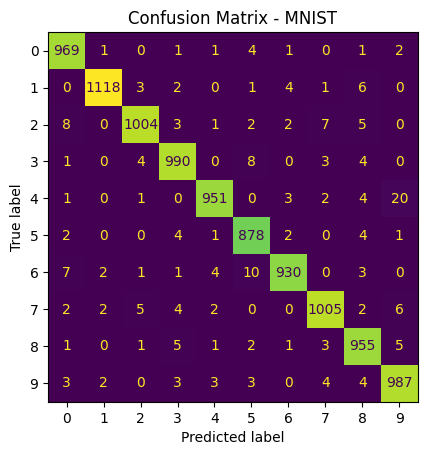

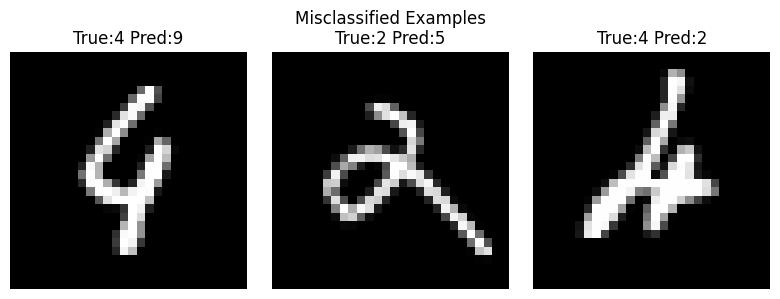

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load & Normalize
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train / 255.0
x_test  = x_test  / 255.0

# Build DNN
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64,  activation='relu'),
    layers.Dense(10,  activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
model.fit(x_train, y_train, epochs=5, batch_size=32, validation_split=0.1)

# Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

# Confusion Matrix
y_pred = np.argmax(model.predict(x_test), axis=1)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=range(10)).plot(colorbar=False)
plt.title("Confusion Matrix - MNIST"); plt.show()

# 3 Misclassified samples
wrong = np.where(y_pred != y_test)[0][:3]
fig, axes = plt.subplots(1, 3, figsize=(8, 3))
for ax, idx in zip(axes, wrong):
    ax.imshow(x_test[idx], cmap='gray')
    ax.set_title(f"True:{y_test[idx]} Pred:{y_pred[idx]}")
    ax.axis('off')
plt.suptitle("Misclassified Examples"); plt.tight_layout(); plt.show()

# Experiment -2




In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=np.float32)
y = np.array([[0],[1],[1],[0]], dtype=np.float32)

model = models.Sequential([
    layers.Dense(4, activation='sigmoid', input_shape=(2,)),
    layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer=optimizers.SGD(learning_rate=0.01),
              loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X, y, epochs=100, verbose=0)
loss, acc = model.evaluate(X, y, verbose=0)
print(f"Exp 1 | Sigmoid | LR=0.01 | Final Loss: {loss:.4f} | Final Acc: {acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Exp 1 | Sigmoid | LR=0.01 | Final Loss: 0.6978 | Final Acc: 0.5000


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=np.float32)
y = np.array([[0],[1],[1],[0]], dtype=np.float32)

model = models.Sequential([
    layers.Dense(4, activation='sigmoid', input_shape=(2,)),
    layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer=optimizers.SGD(learning_rate=0.1),
              loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X, y, epochs=100, verbose=0)
loss, acc = model.evaluate(X, y, verbose=0)
print(f"Exp 2 | Sigmoid | LR=0.1  | Final Loss: {loss:.4f} | Final Acc: {acc:.4f}")

Exp 2 | Sigmoid | LR=0.1  | Final Loss: 0.6966 | Final Acc: 0.5000


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=np.float32)
y = np.array([[0],[1],[1],[0]], dtype=np.float32)

model = models.Sequential([
    layers.Dense(4, activation='relu', input_shape=(2,)),
    layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer=optimizers.SGD(learning_rate=0.01),
              loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X, y, epochs=100, verbose=0)
loss, acc = model.evaluate(X, y, verbose=0)
print(f"Exp 3 | ReLU    | LR=0.01 | Final Loss: {loss:.4f} | Final Acc: {acc:.4f}")

Exp 3 | ReLU    | LR=0.01 | Final Loss: 0.6717 | Final Acc: 0.5000


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=np.float32)
y = np.array([[0],[1],[1],[0]], dtype=np.float32)

model = models.Sequential([
    layers.Dense(4, activation='relu', input_shape=(2,)),
    layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer=optimizers.SGD(learning_rate=0.1),
              loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X, y, epochs=100, verbose=0)
loss, acc = model.evaluate(X, y, verbose=0)
print(f"Exp 4 | ReLU    | LR=0.1  | Final Loss: {loss:.4f} | Final Acc: {acc:.4f}")

Exp 4 | ReLU    | LR=0.1  | Final Loss: 0.6931 | Final Acc: 0.5000
